# Домашнее задание 3 (32 pts)

## Задача 1 (10 pts)

Когда пользователь заходит на сайт, ему показывается одно из $n$ рекламных объявлений, обозначенных $1, \dots, n$. 
Мы делим некоторый временной интервал (скажем, один день) на $T$ периодов, обозначенных $t = 1, \dots, T$.
Пусть $N_{it} \geq 0$ обозначает количество показов рекламы $i$ в период $t$. 
В период $t$ будет всего $I_t > 0$ показов, поэтому мы должны иметь $\sum_{i=1}^n N_{it} = I_t$, для $t = 1, . . . .$ 
(Числа $I_t$ могут быть известны из прошлой истории.) 
Вы можете рассматривать все эти числа как реальные. (Это оправдано, поскольку они обычно очень велики).

Доход от показа рекламы $i$ в период t составляет $R_{it} \geq 0$ за один просмотр. 
(Это может происходить, например, за счет оплаты кликов). 
Общий доход составляет $\sum_{t=1}^{T} \sum_{i=1}^{n} R_{it}N_{it}$. 
Чтобы максимизировать доход, мы просто показываем объявление с наибольшим доходом за показ и никакое другое в каждый период.

У нас также есть набор из $m$ контрактов, которые обязывают нас показывать определенное количество объявлений или их сочетаний (например, связанных с продукцией одной компании) в течение определенных периодов времени, с начислением штрафа за неисполнение. 
Контракт $j$ характеризуется набором объявлений $A_j \subseteq \{1, \dots, n\}$ (хотя это не влияет на математику, они часто не пересекаются), набором периодов $T_j \subseteq \{1, \dots, T \}$, целевым количество показов $q_j \geq 0$ и коэффициентом штрафа $p_j > 0$ за неисполнение.

Размер неисполнения контракта $j$ обозначим $s_j$, которое равно

$$ s_j = \left( q_j - \sum_{i \in A_j} \sum_{t \in T_j}N_{it} \right)_+ ,$$

где $(u)_+ = \max(0, u)$.
Наши контракты задают общую стоимость штрафов равной $\sum_{j=1}^m p_js_j$.
Наша чистая прибыль - это общая выручка минус общая сумма штрафов.

- Покажите, как определить величины $N_{it}$ для максимизации чистой прибыли с помощью решения задачи выпуклой оптимизации. Покажите выпуклость получившейся задачи. Можете считать, что вам известны $R, I$ (это число показов в каждом промежутке, а не единичная матрица), а также данные по контрактам $A_j, T_j, p_j, q_j$ для $j=1,\dots,m$

- Решите получившуюся задачу с помощью cvxpy на основе данных представленных ниже. Данные $A_j$ и $T_j$ представлены в виде бинарных матриц таких что $A^{c}_{ij} = 1$ если $i \in A_j$ и $T^c_{tj} = 1$ если $t \in T_j$.
Укажите оптимальную чистую прибыль, а также соответствующую выручку и общий размер штрафа. 
Приведите те же три числа для стратегии показа в каждом периоде только объявления с наибольшим доходом за показ. Прокомментируйте результат.


In [1]:
import cvxpy as cvx
import numpy as np
from matplotlib import pyplot as plt


# set maximum 10 numbers in a row
np.set_printoptions(precision=3, suppress=True, threshold=10)
np.random.seed(0)

In [2]:
n = 100  # number of ads
m = 30  # number of contracts
T = 60  # number of periods

I = 10 * np.random.rand(T, 1)
# revenue rate for each period and ad
R = np.random.rand(n, T)
q = T / float(n) * 50 * np.random.rand(m, 1)
# penalty rate for shortfall
p = np.random.rand(m, 1)
# one column per contract. 1's at the periods to be displayed
Tcontr = np.array(np.random.rand(T, m) > 0.8, dtype=float)
Acontr = np.zeros((n, m))
for i in range(n):
    contract = int(np.floor(m * np.random.rand()))
    # one column per contract. 1's at the ads to be displayed
    Acontr[i, contract] = 1

### Построение задачи
Эта задача может быть представлена как задача максимизации прибыли:
$$ \text{Maximize} \ income = revenue - penalty ,$$
$$ income = \sum_{t=1}^{T} \sum_{i=1}^{n} R_{it}N_{it} ,$$
$$ penalty = \sum_{j=1}^{m} p_j \left( q_j - \sum_{i \in A_j} \sum_{t \in T_j}N_{it} \right)_+ $$ 
$$ \text{subject to} \ N \geq 0, \sum_{i=1}^{n}N_{it} = I_t$$

Где $income$ - линейная функция, $penalty$ - выпуклая, как сумма функций вида 

$$ c * \max(1 - u^\top x, 0) = \max(c - cu^\top x, 0) ,$$ 

где $c$ - константа, $u$ - бинарный вектор, эта функция - максимум линейной функции и нуля, так что она выпукла, а значит, сумма таких функций - выпуклая функция. В свою очередь, функция $income = revenue - penalty$ - вогнутая, как сумма вогнутых функций ($-penalty$ - вогнутая, $revenue$ - линейная), ограничения также линейны.

### Решение задачи

Матрица $N^\top A_{contr}$ представляет собой количества реклам по контрактам на каждый момент времени: $(N^\top A_{contr})_{jt}$ - количество реклам по контракту $j$ в период времени $t$. Добавим в рассмотрение $T_{contr}$ - время показа рекламы по контрактам, тогда получим, что на главной диагонали матрицы 

$$ (N^\top A_{contr})^\top T_{contr} = A_{contr}^\top N T_{contr} $$

$j$-тое значение соответствует $\sum_{i \in A_j} \sum_{t \in T_j}N_{it}$
тогда штраф можно выразить как:
$$ penalty = p^\top (q - \mathrm{diag}((N^\top A_{contr})^\top T_{contr} = A_{contr}^\top N T_{contr}))_+ $$

In [3]:
N = cvx.Variable((n, T))

revenue = cvx.sum(cvx.multiply(R, N))
penalty = cvx.sum(
    cvx.multiply(p[:, 0], cvx.pos(q[:, 0] - cvx.diag(Acontr.T @ N @ Tcontr)))
)

income = revenue - penalty
objective = cvx.Maximize(income)

constraints = [N >= 0, cvx.sum(N, axis=0, keepdims=True).T == I]

problem = cvx.Problem(objective, constraints)
result = problem.solve()

print(f"Optimal income: {result}")
print(f"Optimal N:\n{N.value}")

Optimal income: 259.0008352942609
Optimal N:
[[-0. -0.  0. ... -0.  0.  0.]
 [ 0.  0.  0. ...  0.  0. -0.]
 [-0.  0.  0. ... -0. -0. -0.]
 ...
 [-0.  0. -0. ... -0. -0. -0.]
 [ 0.  0. -0. ... -0.  0. -0.]
 [-0.  0.  0. ... -0. -0. -0.]]


## Задача 2. (7 pts)
### Задача об изоморфизме графов

Пусть даны два графа $G_A$ и $G_B$ с матрицами смежности $A$ и $B$ соответственно. [Задача об изоморфизме графов](https://en.wikipedia.org/wiki/Graph_isomorphism_problem) состоит в поиске такой матрицы перестановки $P$, что выполнено

$$
PAP^{\top} = B.
$$

На данный момент неизвестно является ли эта задача NP-полной или лежит в классе P.

1) (2 pts) запишите ограничения на искомую матрицу $P$ и покажите, что задача об изоморфизме графа может быть записана как бинарная задача линейного программирования, то есть как задача линейного программирования, в которой элементами решения могут быть только 0 и 1. (**Hint**: подумайте как задачу о существовании некоторого элемента в множестве записать в виде задачи оптимизации)

2) (3 pts) далее рассмотрите релаксацию поставленной задачи, в которой элементы решения могут принимать значения в отрезке $[0, 1]$.
Покажите, что подобная релаксация делает задачу выпуклой. 
Если решение такой задачи не нашлось, то это значит, что графы не изоморфны. Если решение нашлось и элементы решения только 0 или 1, то найдена искомая перестановка. Конечно, такое случается достаточно редко. Чтобы форсировать бинарность элементов решения, к целевой функции исходной задачи можно добавить слагаемое вида $\langle W, P \rangle$, где $W$ некоторая случайная матрица, например с элементами из $\mathcal{N}(0, 1)$ (возможно использование других распределений). Добавление такого слагаемого не повлияет на решение вопроса существования перестановки. 

3) (2 pts) Убедитесь, что графы с матрицами смежности, заданными [тут](https://web.stanford.edu/~boyd/cvxbook/cvxbook_additional_exercises/graph_isomorphism_data.py), являются изоморфными с помощью пакета cvxpy. Для поиска матрицы перестановки, возможно, необходимо решать несколько задач линейного программирования для разных матриц $W$. Также рассмотрите несколько распределений для генерации матрицы $W$. Убедитесь, что найденная матрица действительно является матрицей перестановки. Для проверки бинарности элементов можно отслеживать величину $\max_{(i, j)} P_{ij}(1 - P_{ij})$. После обнаружения матрицы перестановки выведите результат умножения матрицы $P^*$ на вектор $[1, 2, \ldots, n]$ для демонстрации того, как надо переставить вершины исходного графа.

### Решение

1) Линейные ограничения на $P$ - матрицу перестановок могут быть записаны следующим образом: 
   $$ 0 \leq P_{ij} \leq 1, \ \forall i, \ j ,$$ 
   $$ \sum_{i=1}^{n} P_{ij} = 1, \ \forall j ,$$ 
   $$ \sum_{j=1}^{n} P_{ij} = 1, \ \forall i $$ 
   Исходная задача имеет квадратичное условие $PAP^\top = B$, но из-за бинарности матрицы $P$ она может быть сведена к линейной. Заметим, что 
   $$ (PAP^\top)_{ij} = \sum_{l=1}^{n} (PA)_{il} P^\top_{lj} = \sum_{k=1}^{n} \sum_{l=1}^{n} P_{ik} A_{kl} P_{jl} = B_{ij} ,$$
   заменим $X_{ijkl} = P_{ik} P_{jl}$, $X$ - бинарный тензор:
   $$ \sum_{k=1}^{n} \sum_{l=1}^{n} A_{kl} X_{ijkl} = B_{ij} $$
   теперь является линейной функцией. 
   Зададим линейные ограничения на $X$, принимая во внимание, что $X_{ijkl} = 1$ только если $P_{ik} = 1$ и $P_{jl} = 1$:
   $$ X_{ijkl} \leq P_{ik} ,$$
   $$ X_{ijkl} \leq P_{jl} ,$$
   $$ X_{ijkl} \geq P_{ik} + P_{jl} - 1 ,$$
   $$ X_{ijkl} \geq 0 ,$$
   $$ X_{ijkl} \leq 1 ,$$
   $$ \forall i, \ j, \ k, \ l $$
   Так, теперь задача может быть сформулирована в виде задачи линейного программирования:
   $$ \text{Minimize} \ 0 $$
   $$ \text{subject to} $$
   $$ X_{ijkl} \leq P_{ik} ,$$
   $$ X_{ijkl} \leq P_{jl} ,$$
   $$ X_{ijkl} \geq P_{ik} + P_{jl} - 1 ,$$
   $$ X_{ijkl} \geq 0 ,$$ 
   $$ X_{ijkl} \leq 1 ,$$
   $$ \forall i, \ j, \ k, \ l ,$$
   $$ \sum_{k=1}^{n} \sum_{l=1}^{n} A_{kl} X_{ijkl} = B_{ij} \forall i, \ j ,$$
   $$ \sum_{i=1}^{n} P_{ij} = 1, \ \forall j ,$$ 
   $$ \sum_{j=1}^{n} P_{ij} = 1, \ \forall i $$ 
   Минимизируется константа, тогда задача будет состоять в поиске подходящей матрицы перестановки

2) Релаксация, разрешающая элементам $P$ принимать действительные значения из промежутка $[0, 1]$
   делает задачу выпуклой, так как исходная задача - задача линейного программирования, которая является выпуклой

3) Решение задачи выпуклой оптимизации на графах из примера представлено ниже:

In [4]:
A = np.array(
    np.mat(
        "0  1  0  0  0  0  1  0  0  0  1  1  1  0  0  1  0  1  1  0  1  1  0  1  0  1  1  1  0  1;\
 1  0  0  0  0  0  1  1  0  0  1  0  1  0  0  1  1  0  0  0  0  0  0  0  1  0  0  1  1  0;\
 0  0  0  1  1  1  0  0  0  0  1  1  0  1  0  1  0  0  0  1  1  0  1  0  1  1  0  1  1  0;\
 0  0  1  0  0  1  0  0  1  0  0  0  1  1  0  0  0  1  1  1  1  0  0  1  0  0  0  1  0  1;\
 0  0  1  0  0  1  0  0  1  1  0  0  0  0  0  1  0  0  1  0  0  0  0  1  1  0  1  0  0  1;\
 0  0  1  1  1  0  0  1  0  1  1  1  1  0  1  0  1  1  1  1  1  1  1  1  1  1  0  1  1  1;\
 1  1  0  0  0  0  0  1  1  0  0  1  0  0  0  1  0  0  1  0  0  1  0  0  0  0  1  0  1  1;\
 0  1  0  0  0  1  1  0  0  1  1  0  0  1  0  1  0  0  1  0  0  1  1  1  0  1  0  1  0  0;\
 0  0  0  1  1  0  1  0  0  1  1  0  0  1  1  1  1  1  1  0  1  0  0  1  0  0  0  1  0  1;\
 0  0  0  0  1  1  0  1  1  0  0  0  1  1  0  1  0  0  0  0  0  1  0  1  0  0  0  0  0  0;\
 1  1  1  0  0  1  0  1  1  0  0  1  0  0  0  0  1  0  0  0  1  1  0  1  0  1  1  1  0  1;\
 1  0  1  0  0  1  1  0  0  0  1  0  0  0  0  0  1  1  0  0  0  0  0  0  1  0  0  1  1  0;\
 1  1  0  1  0  1  0  0  0  1  0  0  0  1  1  1  0  0  0  0  1  0  1  0  1  1  0  1  1  0;\
 0  0  1  1  0  0  0  1  1  1  0  0  1  0  0  1  0  0  1  0  1  0  0  1  0  0  0  1  0  1;\
 0  0  0  0  0  1  0  0  1  0  0  0  1  0  0  1  0  0  1  1  0  0  0  1  1  0  1  0  0  1;\
 1  1  1  0  1  0  1  1  1  1  0  0  1  1  1  0  0  1  0  1  1  1  1  1  1  1  0  1  1  1;\
 0  1  0  0  0  1  0  0  1  0  1  1  0  0  0  0  0  1  1  0  0  1  0  0  0  0  1  0  1  1;\
 1  0  0  1  0  1  0  0  1  0  0  1  0  0  0  1  1  0  0  1  0  1  1  1  0  1  0  1  0  0;\
 1  0  0  1  1  1  1  1  1  0  0  0  0  1  1  0  1  0  0  1  1  0  0  1  0  0  0  1  0  1;\
 0  0  1  1  0  1  0  0  0  0  0  0  0  0  1  1  0  1  1  0  0  1  0  1  0  0  0  0  0  0;\
 1  0  1  1  0  1  0  0  1  0  1  0  1  1  0  1  0  0  1  0  0  1  0  0  0  0  1  0  0  0;\
 1  0  0  0  0  1  1  1  0  1  1  0  0  0  0  1  1  1  0  1  1  0  0  0  0  0  1  1  0  0;\
 0  0  1  0  0  1  0  1  0  0  0  0  1  0  0  1  0  1  0  0  0  0  0  1  1  1  0  0  0  0;\
 1  0  0  1  1  1  0  1  1  1  1  0  0  1  1  1  0  1  1  1  0  0  1  0  0  1  0  0  1  0;\
 0  1  1  0  1  1  0  0  0  0  0  1  1  0  1  1  0  0  0  0  0  0  1  0  0  1  0  0  1  1;\
 1  0  1  0  0  1  0  1  0  0  1  0  1  0  0  1  0  1  0  0  0  0  1  1  1  0  0  1  0  1;\
 1  0  0  0  1  0  1  0  0  0  1  0  0  0  1  0  1  0  0  0  1  1  0  0  0  0  0  1  1  0;\
 1  1  1  1  0  1  0  1  1  0  1  1  1  1  0  1  0  1  1  0  0  1  0  0  0  1  1  0  0  1;\
 0  1  1  0  0  1  1  0  0  0  0  1  1  0  0  1  1  0  0  0  0  0  0  1  1  0  1  0  0  1;\
 1  0  0  1  1  1  1  0  1  0  1  0  0  1  1  1  1  0  1  0  0  0  0  0  1  1  0  1  1  0"
    ),
    dtype=np.float32,
)

B = np.array(
    np.mat(
        "0  1  0  1  1  1  1  1  1  1  0  1  1  0  1  1  1  0  1  0  1  1  1  1  1  1  0  1  0  1;\
 1  0  1  0  0  0  1  0  1  0  0  0  0  1  0  1  0  1  1  1  0  0  1  1  1  0  0  1  0  0;\
 0  1  0  0  1  0  1  0  1  0  0  0  0  0  0  1  0  1  0  1  1  0  0  0  0  0  0  1  0  1;\
 1  0  0  0  1  0  0  0  1  0  1  1  0  0  0  1  1  1  1  1  1  1  0  1  0  0  0  1  1  0;\
 1  0  1  1  0  0  0  1  0  0  1  0  0  1  0  0  1  0  1  0  0  1  0  0  0  1  0  0  0  0;\
 1  0  0  0  0  0  1  1  1  1  0  1  1  1  1  0  0  0  1  0  1  0  0  0  0  0  0  1  1  1;\
 1  1  1  0  0  1  0  0  1  0  1  0  1  0  1  1  1  1  0  0  0  1  0  1  0  0  1  1  0  0;\
 1  0  0  0  1  1  0  0  0  1  0  0  1  1  1  0  1  0  0  0  1  0  0  0  0  1  1  0  0  1;\
 1  1  1  1  0  1  1  0  0  0  1  1  0  1  0  0  0  1  0  0  0  0  0  0  0  1  0  0  1  0;\
 1  0  0  0  0  1  0  1  0  0  0  0  1  1  0  0  0  0  0  0  0  1  1  1  0  1  0  0  0  0;\
 0  0  0  1  1  0  1  0  1  0  0  1  0  1  0  1  1  0  0  1  1  1  1  0  1  0  0  1  1  0;\
 1  0  0  1  0  1  0  0  1  0  1  0  0  0  0  0  1  0  1  0  0  1  1  0  0  1  0  1  1  0;\
 1  0  0  0  0  1  1  1  0  1  0  0  0  1  0  0  1  1  0  0  0  1  1  1  0  1  0  1  0  0;\
 0  1  0  0  1  1  0  1  1  1  1  0  1  0  0  0  1  1  1  1  1  1  1  1  1  1  1  1  1  1;\
 1  0  0  0  0  1  1  1  0  0  0  0  0  0  0  1  0  1  0  1  0  0  1  0  0  0  0  1  0  1;\
 1  1  1  1  0  0  1  0  0  0  1  0  0  0  1  0  1  0  0  0  0  0  1  0  0  0  1  0  0  1;\
 1  0  0  1  1  0  1  1  0  0  1  1  1  1  0  1  0  1  0  1  1  0  0  0  0  0  0  1  1  1;\
 0  1  1  1  0  0  1  0  1  0  0  0  1  1  1  0  1  0  0  1  0  1  1  0  0  1  1  1  0  0;\
 1  1  0  1  1  1  0  0  0  0  0  1  0  1  0  0  0  0  0  0  0  1  1  0  0  0  0  0  0  0;\
 0  1  1  1  0  0  0  0  0  0  1  0  0  1  1  0  1  1  0  0  0  0  0  1  0  0  1  0  0  1;\
 1  0  1  1  0  1  0  1  0  0  1  0  0  1  0  0  1  0  0  0  0  1  0  0  1  0  0  0  0  0;\
 1  0  0  1  1  0  1  0  0  1  1  1  1  1  0  0  0  1  1  0  1  0  1  1  1  0  0  0  1  1;\
 1  1  0  0  0  0  0  0  0  1  1  1  1  1  1  1  0  1  1  0  0  1  0  0  0  0  0  1  0  0;\
 1  1  0  1  0  0  1  0  0  1  0  0  1  1  0  0  0  0  0  1  0  1  0  0  1  0  1  1  1  0;\
 1  1  0  0  0  0  0  0  0  0  1  0  0  1  0  0  0  0  0  0  1  1  0  1  0  1  0  0  1  0;\
 1  0  0  0  1  0  0  1  1  1  0  1  1  1  0  0  0  1  0  0  0  0  0  0  1  0  1  1  1  1;\
 0  0  0  0  0  0  1  1  0  0  0  0  0  1  0  1  0  1  0  1  0  0  0  1  0  1  0  1  0  1;\
 1  1  1  1  0  1  1  0  0  0  1  1  1  1  1  0  1  1  0  0  0  0  1  1  0  1  1  0  1  0;\
 0  0  0  1  0  1  0  0  1  0  1  1  0  1  0  0  1  0  0  0  0  1  0  1  1  1  0  1  0  0;\
 1  0  1  0  0  1  0  1  0  0  0  0  0  1  1  1  1  0  0  1  0  1  0  0  0  1  1  0  0  0"
    ),
    dtype=np.float32,
)

P = cvx.Variable(A.shape)
W = np.random.normal(size=P.shape)
objective = cvx.Minimize(cvx.trace(W.T @ P))
constraints = [
    P >= 0,
    P <= 1,
    cvx.sum(P, axis=1) == 1,
    cvx.sum(P, axis=0) == 1,
    P @ A == B @ P,
]
problem = cvx.Problem(objective, constraints)
result = problem.solve()

print(f"Optimal P:\n{P.value}")
print(f"P @ A @ P.T == B: {np.allclose(P.value @ A @ P.value.T, B)}")

Optimal P:
[[ 0. -0. -0. ...  0. -0.  0.]
 [ 0.  0.  0. ...  0. -0. -0.]
 [ 0.  0.  0. ... -0. -0. -0.]
 ...
 [ 0.  0.  0. ...  1.  0. -0.]
 [ 0. -0.  0. ...  0. -0.  0.]
 [-0.  0.  0. ... -0.  1.  0.]]
P @ A @ P.T == B: True


In [5]:
# Эта функция проверяет, является ли матрица перестановочной
def check_permutation_matrix(P):
    if P is None:
        return False
    
    if not np.allclose(P * (1 - P), 0):
        return False
    
    n = P.shape[0]
    a = np.arange(n, dtype=P.dtype)
    perm = P @ a
    
    if not np.allclose(np.sort(perm), a):
        return False
    
    return True

In [6]:
check_permutation_matrix(P.value)

True

In [7]:
np.set_printoptions(precision=3, suppress=True, threshold=50)

n = P.value.shape[0]
a = np.arange(1, n + 1, dtype=P.value.dtype)
perm = P.value @ a

# Перестановка вершин для графов из примера:
print(perm)

[16. 22. 27.  9.  5. 13.  1. 25. 21. 23. 19. 14. 26.  6.  2.  7. 30. 11.
 10. 17. 15. 24.  8. 18. 20.  3. 12. 28.  4. 29.]


Проверим, решаема ли задача для других распределений $W$:

In [8]:
W = np.random.exponential(scale=1, size=(n, n))
objective = cvx.Minimize(cvx.trace(W.T @ P))
problem = cvx.Problem(objective, constraints)
result = problem.solve()
print("for exp distribution:", check_permutation_matrix(P.value))

W = np.random.uniform(size=(n, n))
objective = cvx.Minimize(cvx.trace(W.T @ P))
problem = cvx.Problem(objective, constraints)
result = problem.solve()
print("for uniform distribution:", check_permutation_matrix(P.value))

W = np.random.standard_cauchy(size=(n, n))
objective = cvx.Minimize(cvx.trace(W.T @ P))
problem = cvx.Problem(objective, constraints)
result = problem.solve()
print("for cauchy distribution:", check_permutation_matrix(P.value))

for exp distribution: True
for uniform distribution: True
for cauchy distribution: True


## Задача 3 (15 pts)

Онкологический пациент получает дозу облучения $d_t \in \mathbb{R}_+$ в периоды времени $t = 1, \dots, T - 1$, с целью уменьшить опухоль до некоторого заданного целевого размера, при этом минимизируя ущерб здоровью пациента. 
Мы можем выбирать дозы $d_t$ с учетом ограничения $d_t \leq dmax$, где $dmax$ - заданная максимальная доза. 
Пусть $S_t \in \mathbb{R}_+$ обозначает размер опухоли в период $t$. 
Размер опухоли изменяется следующим образом

$$ S_{t+1} = \alpha e^{-\beta d_t} S_t, \quad t=1,\dots,T -1,$$

где $\alpha > 1$ - скорость роста опухоли за период при отсутствии облучения, а $\beta > 0$ - известная константа. 
(Поскольку $d_t \geq 0$ и $\beta > 0$, мы видим, что излучение, примененное в один период, уменьшает опухоль в следующий период). 
Начальный размер опухоли $S_1$ задан. 
Задача состоит в том, чтобы достичь $S_T \leq S_{tar}$, где $S_{tar}$ - целевой конечный размер опухоли.

Пусть $H_t \in \mathbb{R}_+$ обозначает некоторую меру ущерба, нанесенного здоровью пациента в результате лучевой терапии. 
Она изменяется следующим образом

$$ H_{t+1} = \gamma e^{\delta d_t}H_t, \quad t=1,...,T -1,$$

где $\gamma \in (0, 1]$ – скорость восстановления здоровья за период без облучения, а $\delta > 0$ – известная константа. 
(Поскольку $d_t \geq 0$ и $\delta > 0$, мы видим, что излучение, примененное в один период, увеличивает повреждения в следующий период). 
Задано начальное повреждение $H_1$.
Задача состоит в том, чтобы найти серию доз $d_1, \dots, d_{T -1}$, которая удовлетворяет ограничениям, описанным выше, и минимизирует максимальный ущерб $H_{max} = \max_{t=1,\dots,T} H_t$

- (5 pts) Объясните, как решить эту задачу с помощью выпуклой оптимизации. Если вы меняете переменные или формируете релаксацию, вы должны объяснить и обосновать это.

- (10 pts) Решите задачу с помощью пакета cvxpy при $T = 20$ и $dmax =1.2$, $\alpha=1.05$, $\beta=0.6$, $\gamma=0.9$, $\delta=0.3$, $S_1 =1$, $S_{tar} = 0.01$, $H_1 =1$.
Сообщите оптимальное значение целевой функции, т.е. максимальный ущерб. 
Постройте график зависимости дозы $d_t$, ущерба $H_t$ и размера опухоли $S_t$ от $t$ для оптимального плана облучения. 
Постройте аналогичный график для случая, когда лечение не проводится, т.е. $d_t =0$ для $t=1, \dots,T-1$.

### Постановка задачи
Для $t \in {1, 2, ..., T}$ справедливо следующее:

$$ S_t = \alpha^{t-1} e^{-\beta \sum_{i=1}^{t-1} d_i} S_1 ,$$
$$ H_t = \gamma^{t-1} e^{\delta \sum_{i=1}^{t-1} d_i} H_1 .$$

Тогда можно построить задачу выпуклой оптимизации:

$$ \text{Minimize} \ \max_{t \in {1, 2, ..., T}} \gamma^{t-1} e^{\delta \sum_{i=1}^{t-1} d_i} H_1 $$
$$ \text{subject to} \ d \geq 0, \ \alpha^{t-1} e^{-\beta \sum_{i=1}^{t-1} d_i} S_1 \leq S_{tar} $$

Целевая функция выпукла, как максимум из экспонент суммы, экспонента - выпуклая функция, сумма сохраняет выпуклость. По таким же причинам ограничения также выпуклы.

### Решение задачи

In [9]:
H_1 = np.array(1, dtype=np.float32)
S_1 = np.array(1, dtype=np.float32)
S_tar = np.array(0.01, dtype=np.float32)
alpha = np.array(1.05, dtype=np.float32)
beta = np.array(0.6, dtype=np.float32)
gamma = np.array(0.9, dtype=np.float32)
delta = np.array(0.3, dtype=np.float32)
T = 20

d = cvx.Variable(T - 1)

S_T = cvx.power(alpha, T - 1) * cvx.exp(-beta * cvx.sum(d)) * S_1
H_t = [
    cvx.power(gamma, t - 1) * cvx.exp(delta * cvx.sum(d[: t - 1])) * H_1
    for t in range(1, T + 1)
]

constraints = [
    d >= 0,
    S_T <= S_tar,
]

objective = cvx.Minimize(cvx.max(cvx.hstack(H_t)))
problem = cvx.Problem(objective, constraints)
result = problem.solve()

print(f"Optimal H: {result}")
print(f"Optimal d:\n{d.value}")

Optimal H: 2.147363554465016
Optimal d:
[0.087 0.093 0.102 0.113 0.125 0.137 0.15  0.163 0.178 0.196 0.216 0.24
 0.271 0.311 0.367 0.452 0.602 0.961 4.457]


### Графики результатов

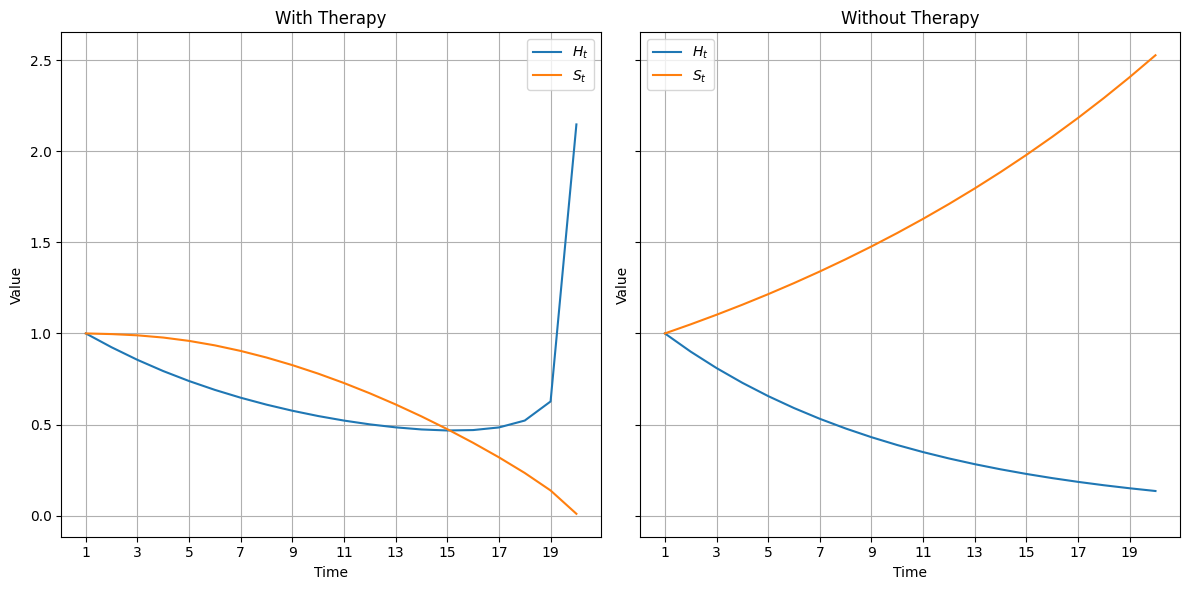

In [10]:
def S_tp1(S_t, d_t, alpha, beta):
    return alpha * S_t * np.exp(-beta * d_t)


def H_tp1(H_t, d_t, gamma, delta):
    return gamma * H_t * np.exp(delta * d_t)


S_therapy = [S_1]
for t in range(T - 1):
    S_therapy.append(S_tp1(S_therapy[-1], d.value[t], alpha, beta))

H_therapy = [H_1]
for t in range(T - 1):
    H_therapy.append(H_tp1(H_therapy[-1], d.value[t], gamma, delta))

S_no_therapy = [S_1]
for t in range(T - 1):
    S_no_therapy.append(S_tp1(S_no_therapy[-1], 0, alpha, beta))

H_no_therapy = [H_1]
for t in range(T - 1):
    H_no_therapy.append(H_tp1(H_no_therapy[-1], 0, gamma, delta))

fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

ax[0].plot(range(1, T + 1), H_therapy, label="$H_t$")
ax[0].plot(range(1, T + 1), S_therapy, label="$S_t$")
ax[0].set_title("With Therapy")
ax[0].legend()
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Value")
ax[0].grid(True)
ax[0].set_xticks(range(1, T + 1, 2))

ax[1].plot(range(1, T + 1), H_no_therapy, label="$H_t$")
ax[1].plot(range(1, T + 1), S_no_therapy, label="$S_t$")
ax[1].set_title("Without Therapy")
ax[1].legend()
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Value")
ax[1].grid(True)


plt.tight_layout()
plt.show()